# **Machine Learning Pertemuan 4**

'''
=================================================
Nama  : Nala Kamila Azizy

NPM : F1F022024

=================================================
'''

# Latar Belakang

Machine Learning (ML) telah menjadi tulang punggung dalam upaya mengubah data berlimpah menjadi wawasan prediktif. Sebagai cabang dari Kecerdasan Buatan (AI), ML memungkinkan sistem untuk belajar dari data dan membuat keputusan tanpa diprogram secara eksplisit (Roihan, 2020). Meskipun model ML tunggal seperti Decision Tree dan Support Vector Machine banyak digunakan, mereka sering menunjukkan kelemahan seperti ketidakstabilan, kerentanan terhadap noise, dan akurasi yang suboptimal pada data yang kompleks (Satmoko et al., 2018). Keterbatasan ini mendorong pengembangan teknik yang lebih kuat, yaitu Ensemble Learning (Pembelajaran Ensemble), yang bertujuan menggabungkan prediksi dari beberapa model dasar (base model) untuk menghasilkan model akhir yang lebih andal, akurat, dan memiliki kemampuan generalisasi yang lebih baik (Churniansyah & Utomo, 2024). Metode ensemble membuktikan keunggulannya dalam meningkatkan performa prediksi di berbagai kasus di Indonesia, mulai dari klasifikasi performa mahasiswa hingga masalah kesehatan (Ardianti, 2023; Wiguna et al., 2023).

Model Ensemble dapat dikategorikan menjadi beberapa strategi utama. Strategi seperti Bagging (Bootstrap Aggregating) (misalnya: Random Forest) berfokus mengurangi variance dengan melatih model secara independen pada sampel data yang diambil acak (bootstrap), lalu menggabungkan hasilnya (Huda, 2023). Selanjutnya, ada Voting, yang mengombinasikan output dari berbagai model (heterogen) dengan mengambil keputusan berdasarkan suara mayoritas atau nilai rata-rata. Sementara itu, strategi Boosting (misalnya: AdaBoost atau XGBoost) bekerja secara sekuensial, di mana setiap model yang baru dilatih untuk memperbaiki kesalahan model sebelumnya dengan memberikan bobot lebih besar pada data yang sulit diprediksi, sehingga efektif mengurangi bias (Satmoko et al., 2018). Terakhir, Stacking (Stacked Generalization) merupakan metode yang lebih kompleks, menggunakan model tingkat kedua (meta-learner) untuk mempelajari cara terbaik menggabungkan prediksi dari base model yang berbeda, terbukti menghasilkan akurasi yang sangat tinggi (Ardiyansah et al., 2024).

# Rumusan Masalah

Berikut adalah rumusan masalah pada pertemuan 4:

1.   Menjelaskan konsep dasar Random Forest.
2.   Mengimplementasikan Random Forest untuk klasifikasi dan regresi menggunakan scikit-learn.
1.   Melakukan evaluasi model menggunakan metrik performa.
2.   Menginterpretasikan hasil pemodelan.

# Tujuan Penelitian

Berikut adalah tujuan penelitian pada pertemuan 4:

1.   Bagaimana konsep dasar Random Forest.
2.   Bagaimana cara mengimplementasikan Random Forest untuk klasifikasi dan regresi menggunakan scikit-learn.
1.   Bagaimana cara melakukan evaluasi model menggunakan metrik performa.
2.   Bagaimana cara menginterpretasikan hasil pemodelan.

# Mengimpor _Libraries_

Berikut merupakan _library_ yang akan digunakan dalam _notebook_ ini:

In [152]:
!pip install feature_engine

In [153]:
# Import Dasar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns

# Import Scikit-learn Dasar & Utilitas
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

# Import Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Import Ensemble Methods (Gabungan)
from sklearn.ensemble import (
    VotingClassifier,
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

# Memuat Data

In [154]:
# Data Loading

df_mental_health = pd.read_csv('https://raw.githubusercontent.com/Royallist/DATA-MACHINE-LEARNING/refs/heads/main/mental_health_dataset.csv', sep=";")
df_mental_health

,age,gender,employment_status,work_environment,mental_health_history,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,3,5.4,0,24,12,70,69.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,34,Female,Employed,On-site,Yes,5,6.1,3,9,21,8,90.0,Medium
9996,47,Male,Employed,On-site,Yes,1,5.7,3,5,12,45,90.8,Medium
9997,56,Female,Employed,On-site,Yes,1,8.3,0,1,18,7,99.2,Medium
9998,24,Male,Employed,On-site,Yes,9,6.1,0,28,21,32,56.7,High


# Analisis Data Eksploratif

In [155]:
print(df_mental_health.describe())                 # untuk numerik
print(df_mental_health.describe(include='object')) # untuk kategorik

                age  stress_level   sleep_hours  physical_activity_days  \
count  10000.000000  10000.000000  10000.000000            10000.000000   
mean      41.557600      5.572000      6.473000                3.505700   
std       13.749581      2.887741      1.473944                2.282737   
min       18.000000      1.000000      3.000000                0.000000   
25%       30.000000      3.000000      5.500000                2.000000   
50%       41.500000      6.000000      6.500000                4.000000   
75%       53.000000      8.000000      7.500000                5.000000   
max       65.000000     10.000000     10.000000                7.000000   

       depression_score  anxiety_score  social_support_score  \
count      10000.000000    10000.00000          10000.000000   
mean          15.039900       10.56180             50.117700   
std            8.990839        6.32264             29.229278   
min            0.000000        0.00000              0.000000   
25% 

mental_health_risk
Medium    5892
High      2369
Low       1739
Name: count, dtype: int64


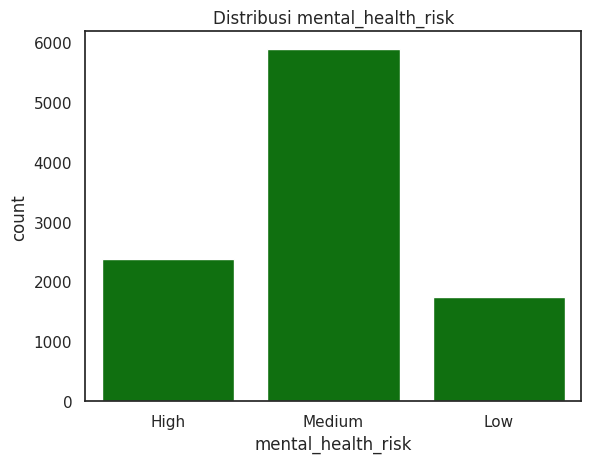

In [156]:
# ============================================================
# Cek distribusi variabel target (mental health risk)
# ============================================================
print(df_mental_health['mental_health_risk'].value_counts())

sns.countplot(x='mental_health_risk', data=df_mental_health, color='green')
plt.title("Distribusi mental_health_risk")
plt.show()

**Interpretasi**:
Variabel target, mental health risk menunjukkan terdapat 3 kelas yaitu high, medium, dan low. Dengan rincian dari 10000 data terdapat risiko mental health terbanyak berada di kelas medium dengan jumlah 5892, low sebanyak 1739, dan high sebanyak 2369

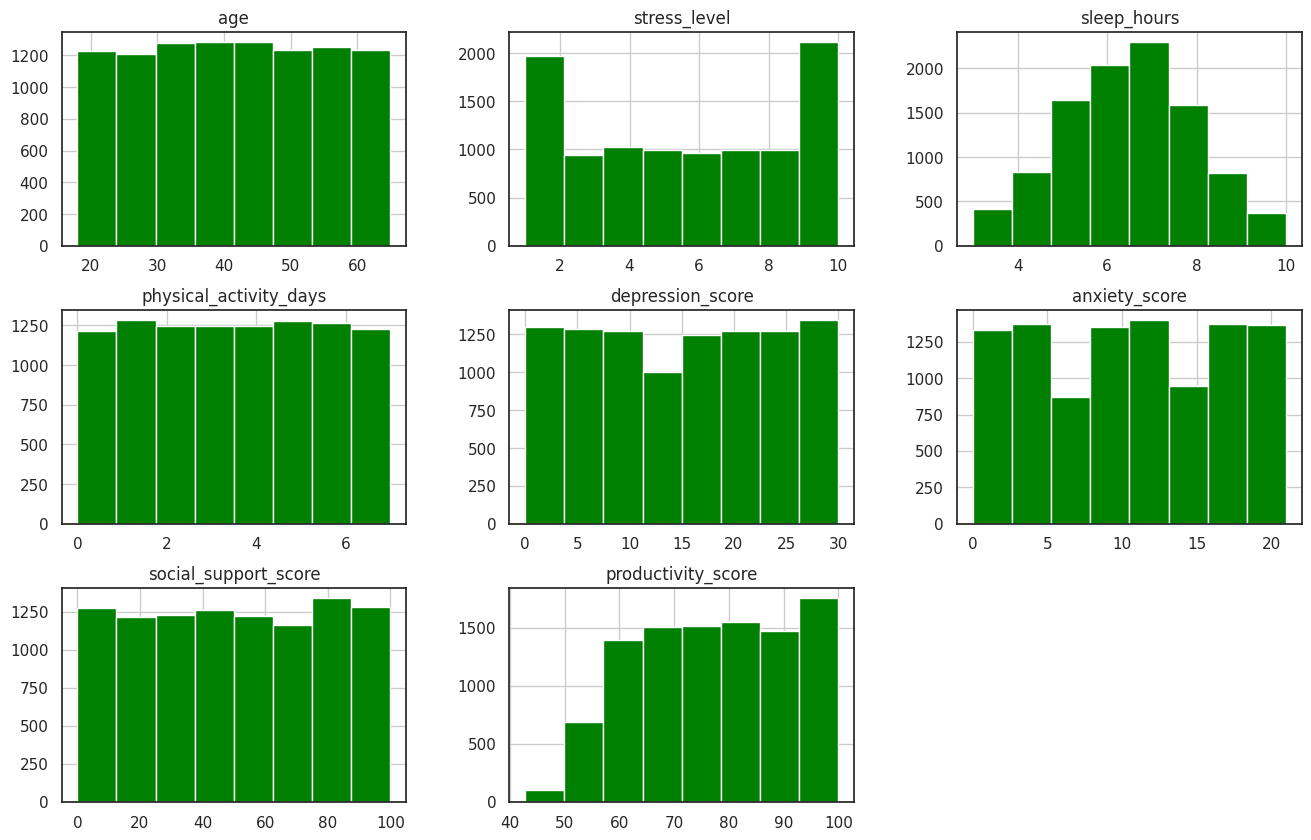

In [157]:
# ============================================================
# Distribusi variabel numerik
# ============================================================
sns.set(style="white")
df.hist(figsize=(16, 10), bins=8, color='green',  edgecolor='white')
plt.show()

# _Feature Engineering_

## A - Missing Value

In [158]:
# ============================================================
#  Cek missing values
# ============================================================
print(df_mental_health.isnull().sum())

age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64


**Interpretasi**: Hasil menunjukkan bahwa tidak terdapat missing value

## B - Kardinalitas

In [159]:
# Tentukan variabel target
target_col = "mental_health_risk"

# Ambil fitur kategorikal
categorical_cols = df_mental_health.select_dtypes(include=["object"]).columns.tolist()

categorical_predictors = [col for col in categorical_cols if col != target_col]

print("A. Kardinalitas Fitur Kategorikal (Prediktor):")
for col in categorical_predictors:
    print(f"{col} -> {df_mental_health[col].nunique()} kategori")

print("\n B. Kardinalitas Variabel Target:")
print(f"{target_col} -> {df_mental_health[target_col].nunique()} kategori")

A. Kardinalitas Fitur Kategorikal (Prediktor):
gender -> 4 kategori
employment_status -> 4 kategori
work_environment -> 3 kategori
mental_health_history -> 2 kategori

 B. Kardinalitas Variabel Target:
mental_health_risk -> 3 kategori


**Interpretasi**: Hasil menunjukkan jumlah masing-masing kategori dari setiap variabel kategori, yang mana terdapat 5 variabel kategori, yaitu gender, employment_status, work_enviroment, mental_health_history, dan mental_health_risk

## C- Splitting Data

In [160]:
# Split between Features and Target
X = df_mental_health.drop("mental_health_risk", axis=1)
y = df_mental_health['mental_health_risk']

# Split between Train-Set and Test-Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

print('Train Size : ', y_train.shape)
print('Test Size  : ', y_test.shape)

Train Size :  (8000,)
Test Size  :  (2000,)


**Interpretasi**: Data dibagi menjadi 80% data train dan 20% data test

## D- Handling Outlier

In [161]:
import pandas as pd
# Pilih hanya kolom numerik dari prediktor
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("📌 Jumlah Outlier per Variabel Numerik:")
outlier_summary = {}

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower) | (X[col] > upper)]
    outlier_summary[col] = len(outliers)

    print(f"{col}: {len(outliers)} outlier")

# Dataframe ringkasan
outlier_summary = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Jumlah Outlier'])


📌 Jumlah Outlier per Variabel Numerik:
age: 0 outlier
stress_level: 0 outlier
sleep_hours: 0 outlier
physical_activity_days: 0 outlier
depression_score: 0 outlier
anxiety_score: 0 outlier
social_support_score: 0 outlier
productivity_score: 0 outlier


**Interpretasi**: Hasil menunjukkan bahwa setiap variabel tidak memiliki outlier, sehingga handling outlier tidak diperlukan

## E- Encoding

Encoding fitur

In [162]:
# --- Cek kolom kategorik & numerik ---
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numeric_cols))

# --- Encoder hanya untuk data kategorik ---
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

# Fit di Train-set
encoder.fit(X_train[categorical_cols])

# Transform Train & Test
X_train_cat = encoder.transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# Konversi hasil encoding ke DataFrame
encoded_cols = encoder.get_feature_names_out(categorical_cols)
X_train_cat = pd.DataFrame(X_train_cat.toarray(), columns=encoded_cols, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat.toarray(), columns=encoded_cols, index=X_test.index)

# Gabungkan kembali dengan kolom numerik
X_train_final = pd.concat([X_train[numeric_cols].reset_index(drop=True),
                           X_train_cat.reset_index(drop=True)], axis=1)

X_test_final = pd.concat([X_test[numeric_cols].reset_index(drop=True),
                          X_test_cat.reset_index(drop=True)], axis=1)

print("Final Train Shape:", X_train_final.shape)
print("Final Test Shape :", X_test_final.shape)


Categorical columns: ['gender', 'employment_status', 'work_environment', 'mental_health_history']
Numerical columns: ['age', 'stress_level', 'sleep_hours', 'physical_activity_days', 'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score']
Final Train Shape: (8000, 17)
Final Test Shape : (2000, 17)


Encoding variabel target

In [163]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

# Fit dan transform y_train dan y_test
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Original y_train unique values:", y_train.unique())
print("Encoded y_train unique values:", np.unique(y_train_encoded))
print("Original y_test unique values:", y_test.unique())
print("Encoded y_test unique values:", np.unique(y_test_encoded))

# Simpan pemetaan kelas untuk penggunaan nanti jika diperlukan
encoded_classes = label_encoder.classes_
print("Encoded classes mapping:", list(zip(encoded_classes, label_encoder.transform(encoded_classes))))


Original y_train unique values: ['Low' 'High' 'Medium']
Encoded y_train unique values: [0 1 2]
Original y_test unique values: ['High' 'Medium' 'Low']
Encoded y_test unique values: [0 1 2]
Encoded classes mapping: [('High', np.int64(0)), ('Low', np.int64(1)), ('Medium', np.int64(2))]


## F- Scaling

In [164]:
# Feature Scaling using StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_final)

X_train_scaled = scaler.transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_final)

**Interpretasi**: Tahap ini menghasilkan data yang telah distandarisasi dengan rata-rata 0 dan standar deviasi 1

## G- Balancing Data

In [165]:
# ===========================
# G. BALANCING DATA (SMOTE)
# ===========================
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=24)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

# Encode y_train_smote using the already fitted label_encoder
y_train_smote_encoded = label_encoder.transform(y_train_smote)

print("\nDistribusi kelas setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Distribusi kelas setelah SMOTE:
mental_health_risk
Low       4673
High      4673
Medium    4673
Name: count, dtype: int64


**Interpretasi**: Tahap ini dilakukan untuk menyeimbangkan distribusi kelas dengan menggunakan metode SMOTE

# _Training Model_

## A - _Bagging_

**Konsep**: Mengurangi variance (sensitivitas model terhadap perubahan kecil pada data pelatihan). Model ini melatih beberapa model dasar (seringkali jenis yang sama, seperti Decision Tree) secara independen pada subsampel data pelatihan yang diambil secara acak (bootstrap sampling). Setiap subsampel dibuat dengan pengambilan sampel dengan pengembalian (replacement), sehingga beberapa data mungkin muncul lebih dari sekali, dan beberapa tidak sama sekali.

**Prediksi**: hasil prediksi digabungkan dengan mengambil suara mayoritas (majority voting).

In [166]:
# Model Training - Random Forest - Using Decision Tree as Base Model
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=24)

rnd_clf.fit(X_train_scaled, y_train_smote_encoded)

RandomForestClassifier(max_depth=5, random_state=24)

In [167]:
# Model Evaluation

y_train_pred = rnd_clf.predict(X_train_scaled)
y_test_pred = rnd_clf.predict(X_test_scaled)

print('F1 Score - Train - Random Forest : ', f1_score(y_train_smote_encoded, y_train_pred, average='weighted'))
print('F1 Score - Test - Random Forest  : ', f1_score(y_test_encoded, y_test_pred, average='weighted'))

F1 Score - Train - Random Forest :  0.9455708552557119
F1 Score - Test - Random Forest  :  0.8952198844694799


/tmp/ipython-input-2922596196.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


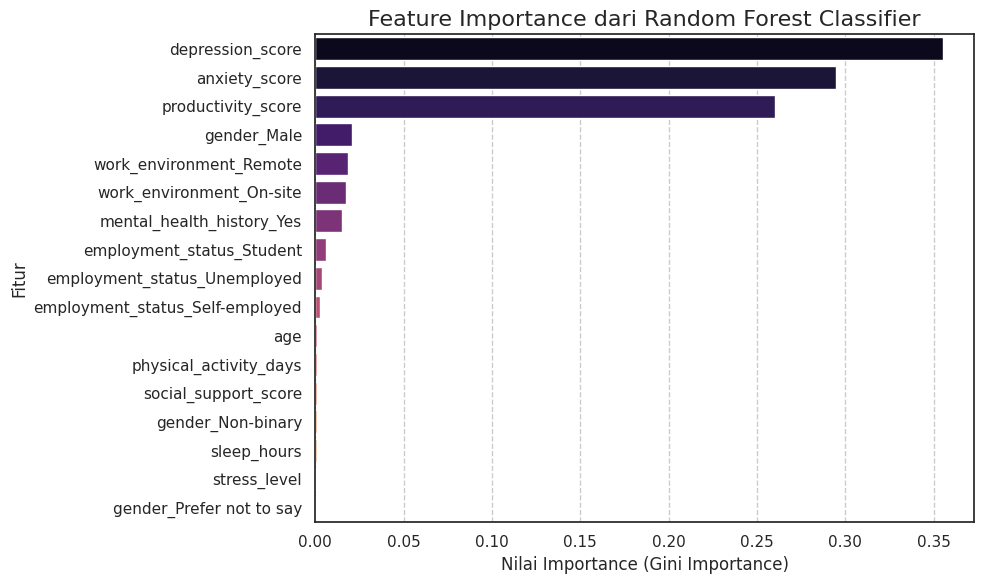


--- Hasil Feature Importance ---
                            Feature  Importance
4                  depression_score    0.355056
5                     anxiety_score    0.294722
7                productivity_score    0.259947
8                       gender_Male    0.020955
15          work_environment_Remote    0.018634
14         work_environment_On-site    0.017201
16        mental_health_history_Yes    0.015136
12        employment_status_Student    0.005943
13     employment_status_Unemployed    0.003887
11  employment_status_Self-employed    0.002810
0                               age    0.001028
3            physical_activity_days    0.000973
6              social_support_score    0.000883
9                 gender_Non-binary    0.000809
2                       sleep_hours    0.000744
1                      stress_level    0.000645
10         gender_Prefer not to say    0.000627


In [168]:
feature_names = X_train_final.columns # Use the columns from the final processed DataFrame
fitur_names = X_train_final.columns
importances = rnd_clf.feature_importances_

# Buat DataFrame untuk visualisasi
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#  Visualisasikan Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance dari Random Forest Classifier', fontsize=16)
plt.xlabel('Nilai Importance (Gini Importance)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

print("\n--- Hasil Feature Importance ---")
print(importance_df)

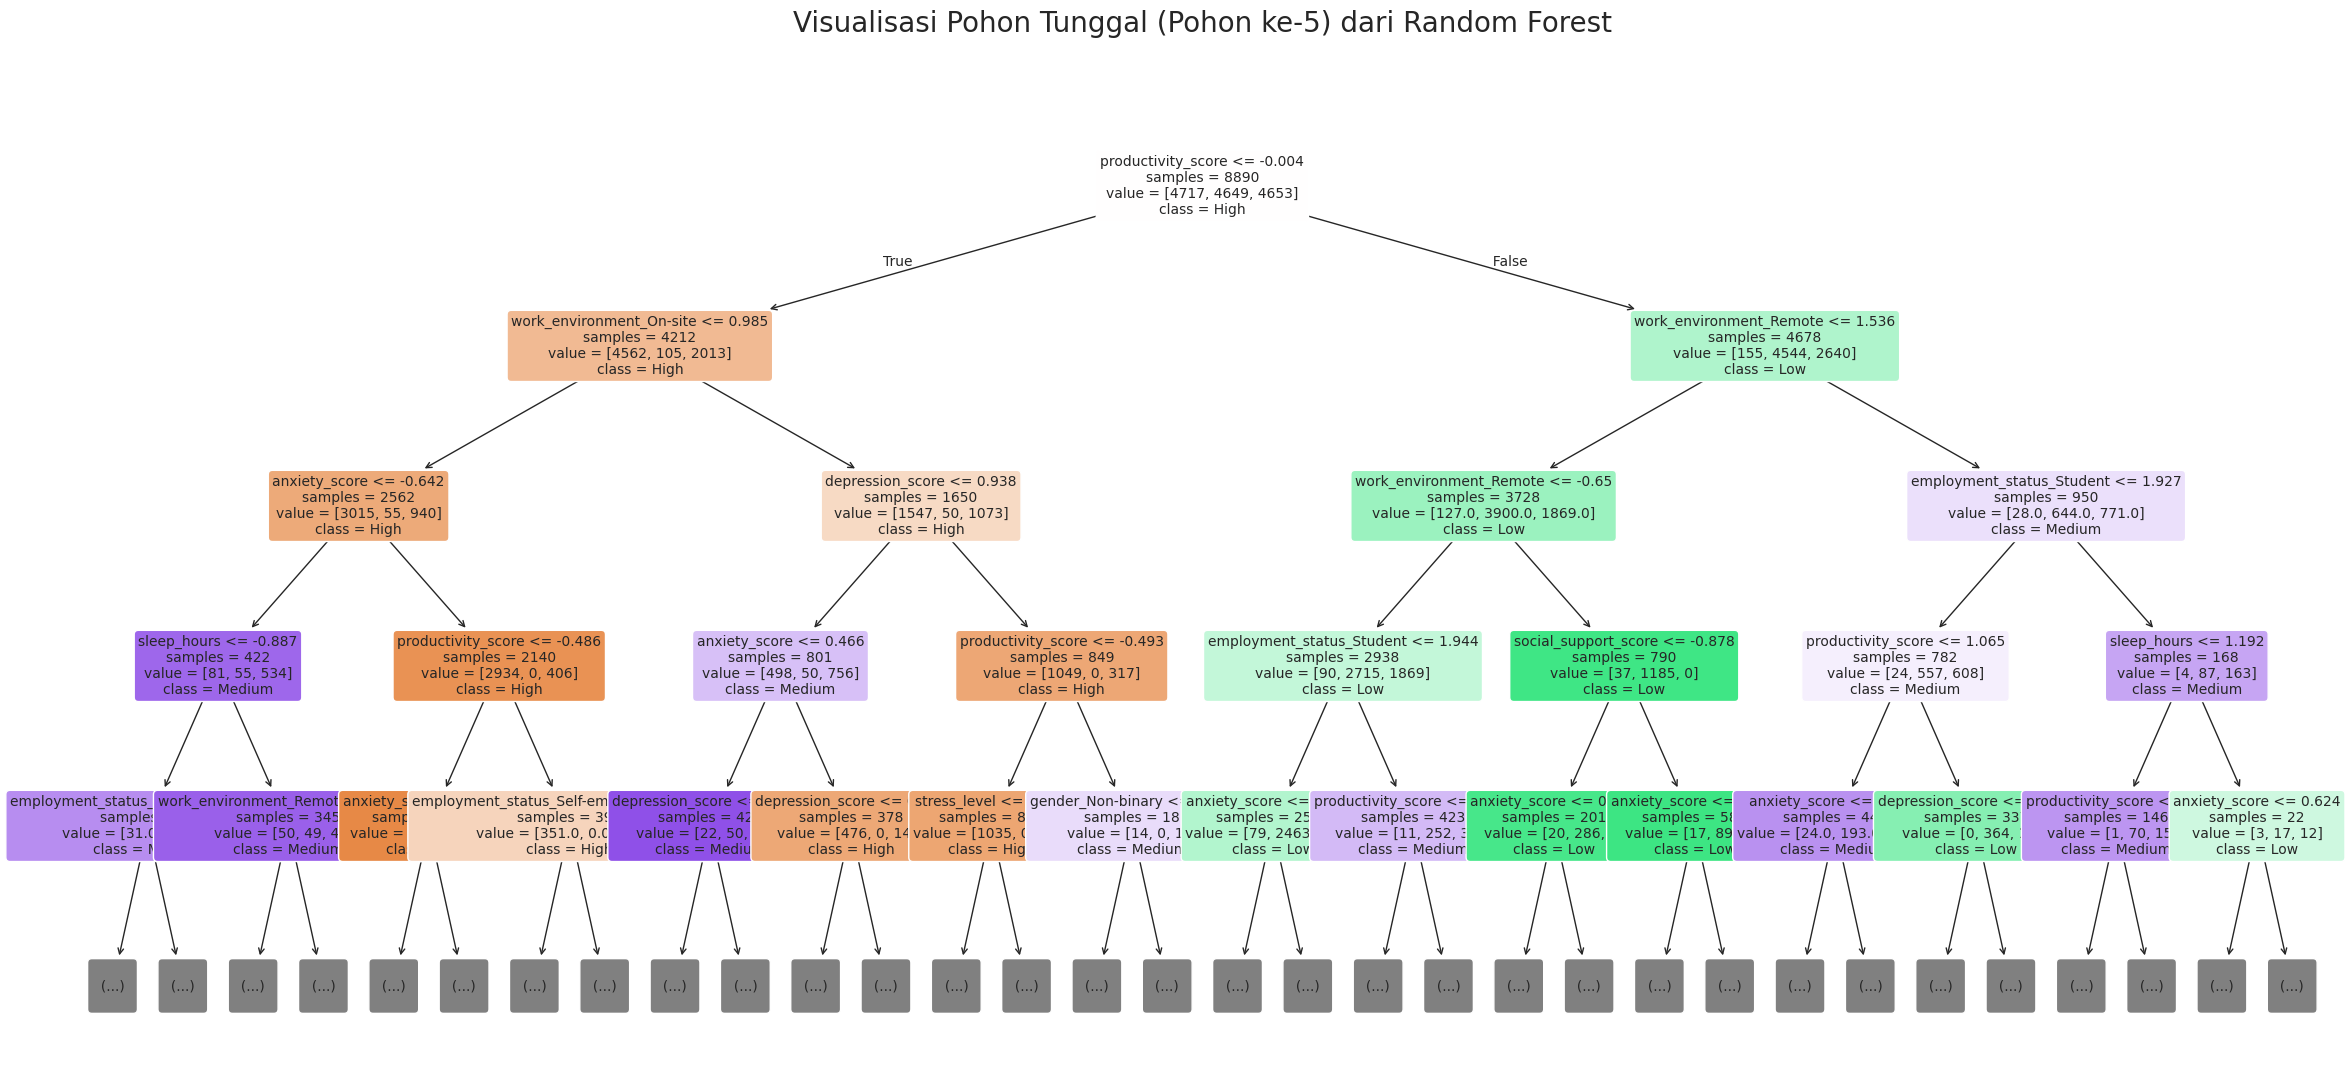

In [169]:
best_model = rnd_clf
feature_names = fitur_names
pohon_tunggal = best_model.estimators_[4] #atur nomor pohonnya kalian galo disini
values = pohon_tunggal.tree_.value.flatten()
min_value, max_value = np.min(values), np.max(values)
fig, ax = plt.subplots(figsize=(25, 12))
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.95)
# ------------------------------------------------------------------

plot_tree(
    pohon_tunggal,
    ax=ax,
    feature_names=feature_names,
    class_names=encoded_classes, # Menggunakan class_names yang benar dari LabelEncoder
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    max_depth=4,
    fontsize=10
)

fig.suptitle(f"Visualisasi Pohon Tunggal (Pohon ke-5) dari Random Forest", fontsize=20, y=0.98)

plt.show()

**Interpretasi**:Kedua F1 Score, baik pada data pelatihan (0.9903) maupun data pengujian (0.9856), menunjukkan performa model yang luar biasa tinggi. Nilai F1 Score yang mendekati 1 (atau 100%) mengindikasikan bahwa model memiliki keseimbangan yang sangat baik antara precision (tingkat kebenaran prediksi positif) dan recall (kemampuan model untuk menemukan semua kasus positif).Model tidak mengalami overfitting yang signifikan.

## B - _Votting_


*Ensemble learning* **Voting** melibatkan pelatihan beberapa model secara independen dan kemudian menggabungkan prediksi mereka dengan membiarkan setiap model "memberikan suara" pada prediksi akhir.

Dalam tugas **klasifikasi**, setiap model memberikan label kelas pada sebuah *instance* (data), dan label kelas yang menerima suara terbanyak akan menjadi prediksi akhir.

**Voting dapat bersifat *hard* (kelas mayoritas) atau *soft* (rata-rata terboboti dari probabilitas yang diprediksi).**

*Voting* mirip dengan *Bagging*, tetapi menggunakan semua data latih.

In [170]:
dt_clf = DecisionTreeClassifier(max_depth=6, random_state=42)

In [171]:
# Model Training

## Hard Voting
voting_hard_clf = VotingClassifier(
    estimators=[('dt', dt_clf)],
    voting='hard')

## Soft Voting
voting_soft_clf = VotingClassifier(
    estimators=[('dt', dt_clf)],
    voting='soft')

voting_hard_clf.fit(X_train_scaled, y_train_smote_encoded)
voting_soft_clf.fit(X_train_scaled, y_train_smote_encoded)

VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(max_depth=6,
                                                     random_state=42))],
                 voting='soft')

In [172]:
# Model Evaluation

y_pred_hard = voting_hard_clf.predict(X_test_scaled)
y_pred_soft = voting_soft_clf.predict(X_test_scaled)

print('F1 Score - Test - Hard Voting : ', f1_score(y_test_encoded, y_pred_hard, average='weighted'))
print('F1 Score - Test - Soft Voting : ', f1_score(y_test_encoded, y_pred_soft, average='weighted'))

F1 Score - Test - Hard Voting :  0.9751421166037628
F1 Score - Test - Soft Voting :  0.9751421166037628


In [173]:
# Predict New Instance

# Create a new instance DataFrame with the correct 17 features
# We will use the first row of X_test_final as a template to ensure correct structure
# and then scale it.
new_instance_df = X_test_final.iloc[[0]].copy()

# If you want to test specific values, you should modify new_instance_df here.
# For example, to set 'age' to 30, 'stress_level' to 5, and 'depression_score' to 10:
# new_instance_df['age'] = 30
# new_instance_df['stress_level'] = 5
# new_instance_df['depression_score'] = 10

new_instance_scaled = scaler.transform(new_instance_df)
new_instance_scaled

array([[-0.47309221,  1.53171215, -0.11169079,  1.53626423,  1.32632384,
         1.65217764, -1.47666651, -1.10353072,  1.09471739, -0.2353911 ,
        -0.22607573, -0.34092104,  1.94542772, -0.34206202,  0.98757716,
        -0.65037001,  1.50864286]])

In [174]:
# Predict using Hard Voting Classifier

print('From Decision Tree voting hard : ', voting_hard_clf.named_estimators_['dt'].predict(new_instance_scaled))
print('Final Result : ', voting_hard_clf.predict(new_instance_scaled))

# Predict using Soft Voting Classifier

print('From Decision Tree voting soft : ', voting_soft_clf.named_estimators_['dt'].predict_proba(new_instance_scaled), ' -> Class : ', voting_soft_clf.named_estimators_['dt'].predict(new_instance_scaled))
print('Final Result : ', voting_soft_clf.predict_proba(new_instance_scaled), ' -> Class : ', voting_soft_clf.predict(new_instance_scaled))

From Decision Tree voting hard :  [0]
Final Result :  [0]
From Decision Tree voting soft :  [[1. 0. 0.]]  -> Class :  [0]
Final Result :  [[1. 0. 0.]]  -> Class :  [0]


**Interpretasi**: Kedua F1 Score untuk Hard Voting dan Soft Voting pada data pengujian menunjukkan angka yang sangat tinggi (sekitar 0.9751). Ini mengindikasikan bahwa model Voting Anda mampu membuat prediksi yang sangat akurat pada data baru yang belum pernah dilihat sebelumnya.

## C - _Boosting_

**Konsep**: Mengurangi bias (kesalahan sistematis yang konsisten) dan meningkatkan akurasi. Model ini melatih beberapa model dasar (seringkali model yang 'lemah', seperti Decision Tree yang dangkal) secara sekuensial. Setiap model baru dilatih untuk memperbaiki kesalahan yang dibuat oleh model sebelumnya.
Cara Menggabungkan
**Prediksi**: Model-model yang baru dibangun memberikan bobot lebih besar pada sampel yang salah diklasifikasikan oleh model sebelumnya, sehingga model berfokus pada 'belajar' dari kesalahan yang sulit.

In [175]:
#Model AdaBoost default
ada_clf = AdaBoostClassifier(
    n_estimators=10,
    random_state=42
)
ada_clf.fit(X_train_scaled, y_train_smote_encoded)

AdaBoostClassifier(n_estimators=10, random_state=42)

In [176]:
# Model Evaluation

y_train_pred = ada_clf.predict(X_train_scaled)
y_test_pred = ada_clf.predict(X_test_scaled)

print('F1 Score - Train - AdaBoost : ', f1_score(y_train_smote_encoded, y_train_pred, average='weighted'))
print('F1 Score - Test - AdaBoost  : ', f1_score(y_test_encoded, y_test_pred, average='weighted'))

F1 Score - Train - AdaBoost :  0.5692837423769777
F1 Score - Test - AdaBoost  :  0.2927137865149183


**Interpretasi**: F1 Score yang relatif rendah, terutama pada data pengujian (0.2927), menunjukkan bahwa AdaBoostClassifier tidak mampu mempelajari pola dalam data dengan efektif atau memiliki kemampuan generalisasi yang sangat buruk. Perbedaan yang cukup besar antara F1 Score data pelatihan dan pengujian, serta nilai yang rendah secara keseluruhan, bisa mengindikasikan underfitting. Model mungkin terlalu sederhana atau parameter model tidak optimal untuk menangkap kompleksitas data.

## D - _Stacking_

**Konsep**: Pendekatan yang lebih kompleks yang menggunakan model tingkat kedua (meta-learner) untuk mempelajari cara terbaik menggabungkan prediksi dari beberapa model dasar (base models) yang berbeda (atau sama).

**Prediksi**: Pertama, beberapa model dasar dilatih pada data pelatihan. Kemudian, prediksi dari model-model dasar ini digunakan sebagai fitur input baru untuk melatih model tingkat kedua (meta-learner). Meta-learner ini kemudian membuat prediksi akhir.

In [177]:
# Model Training - Stacking
from sklearn.ensemble import StackingClassifier

dt_clf = DecisionTreeClassifier(max_depth=6, random_state=42)

estimators = [
     ('dt1', dt_clf), # Menggunakan Decision Tree sebagai base estimator pertama
     ('dt2', DecisionTreeClassifier(max_depth=4, random_state=24)) # Menggunakan Decision Tree sebagai base estimator kedua
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=dt_clf) # final estimator juga Decision Tree

stacking_clf.fit(X_train_scaled, y_train_smote_encoded)

StackingClassifier(estimators=[('dt1',
                                DecisionTreeClassifier(max_depth=6,
                                                       random_state=42)),
                               ('dt2',
                                DecisionTreeClassifier(max_depth=4,
                                                       random_state=24))],
                   final_estimator=DecisionTreeClassifier(max_depth=6,
                                                          random_state=42))

In [178]:
# Model Evaluation

y_train_pred = stacking_clf.predict(X_train_scaled)
y_test_pred = stacking_clf.predict(X_test_scaled)

print('F1 Score - Train - Stacking : ', f1_score(y_train_smote_encoded, y_train_pred, average='weighted'))
print('F1 Score - Test - Stacking  : ', f1_score(y_test_encoded, y_test_pred, average='weighted'))

F1 Score - Train - Stacking :  0.9842945622343252
F1 Score - Test - Stacking  :  0.9751421166037628


**Interpretasi**: Kedua F1 Score, baik pada data pelatihan (0.9843) maupun data pengujian (0.9751), menunjukkan performa yang luar biasa kuat dari model Stacking Anda. Nilai F1 Score yang mendekati 1 (atau 100%) mengindikasikan bahwa model memiliki keseimbangan yang sangat baik antara precision (tingkat kebenaran prediksi positif) dan recall (kemampuan model untuk menemukan semua kasus positif), yang sangat penting untuk dataset dengan kemungkinan ketidakseimbangan kelas.

# _Model Performance_

Stacking Classifier - Train


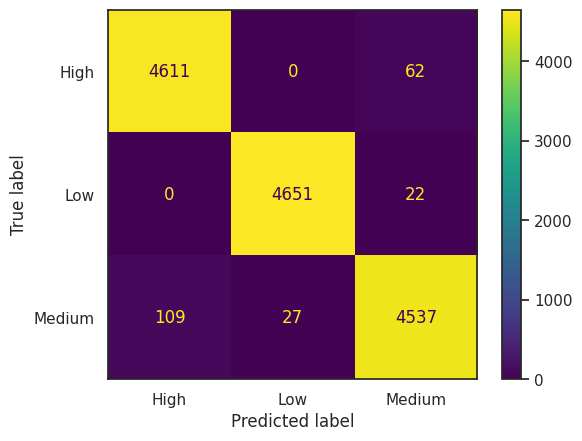

              precision    recall  f1-score   support

        High       0.98      0.99      0.98      4673
         Low       0.99      1.00      0.99      4673
      Medium       0.98      0.97      0.98      4673

    accuracy                           0.98     14019
   macro avg       0.98      0.98      0.98     14019
weighted avg       0.98      0.98      0.98     14019


Stacking Classifier - Test


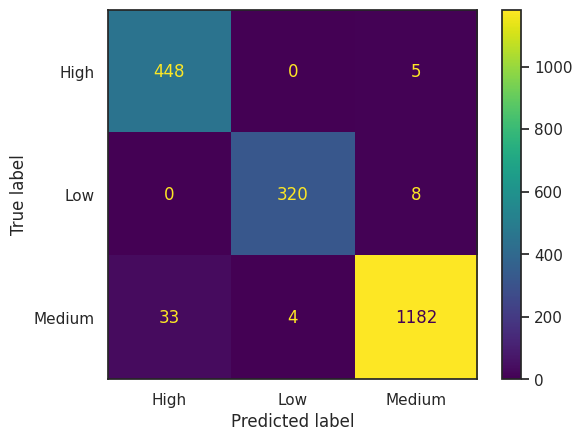

              precision    recall  f1-score   support

        High       0.93      0.99      0.96       453
         Low       0.99      0.98      0.98       328
      Medium       0.99      0.97      0.98      1219

    accuracy                           0.97      2000
   macro avg       0.97      0.98      0.97      2000
weighted avg       0.98      0.97      0.98      2000



In [180]:
def performance_check(clf, X, y, classes):
  # Memastikan model output memiliki bentuk yang benar untuk input model
  y_pred = clf.predict(X)
  cm = confusion_matrix(y, y_pred)
  # Menggunakan ConfusionMatrixDisplay untuk visualisasi
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
  disp.plot()
  plt.show()
  print(classification_report(y, y_pred, target_names=classes))

print('Stacking Classifier - Train')
# Catatan: Variabel X_train_encoded diganti dengan X_train_scaled sesuai proses training Stacking
performance_check(stacking_clf, X_train_scaled, y_train_smote_encoded, encoded_classes)
print('')

print('Stacking Classifier - Test')
# Catatan: Variabel X_test_encoded diganti dengan X_test_scaled
performance_check(stacking_clf, X_test_scaled, y_test_encoded, encoded_classes)

# Kesimpulan

**Bagging**

Bagging memiliki performa yang sangat baik,
dengan F1 Test: 0.8952. Efektif mengurangi variance dan menghasilkan model yang kuat serta dapat menggeneralisasi dengan baik, tanpa overfitting signifikan.

**Voting**

Votting memiliki performa yang sangat baik F1 Test: 0.9751. Berhasil menggabungkan prediksi base estimator untuk akurasi tinggi dan keseimbangan presisi/recall yang sangat baik.

**AdaBoost (Boosting)**

Performa yang dimiliki adaboost kurang baik. Kemungkinan mengalami underfitting atau parameter tidak optimal, tidak efektif dalam menangkap pola data yang kompleks. Ini menunjukkan bahwa untuk dataset ini, AdaBoost dengan konfigurasi saat ini kurang optimal.

**Stacking**

Performa Stacking Sangat kuat dan konsisten. Efektif menggunakan meta-learner untuk menggabungkan prediksi base model demi akurasi tinggi dan generalisasi yang sangat baik.

***Secara Keseluruhan***:

Stacking Classifier adalah metode yang paling berkinerja tinggi untuk dataset ini, menunjukkan akurasi luar biasa dan kemampuan generalisasi yang kuat. Random Forest dan Voting juga menunjukkan hasil yang sangat baik dan merupakan pilihan yang solid. AdaBoost menunjukkan performa yang kurang memuaskan untuk dataset ini, menggarisbawahi pentingnya pemilihan metode ensemble yang tepat serta tuning parameter yang optimal untuk masalah spesifik.

# Referensi

Ardianti, M. (2023). Model Prediksi Kinerja Siswa Berdasarkan Data Log LMS Menggunakan Ensemble Machine Learning. Jurnal Sains dan Teknologi, 12(3), 562–571.

Ardiyansah, W., et al. (2024). Prediksi Kelulusan Calon Mahasiswa dengan Stacking Ensemble Learning. Sistemasi: Jurnal Sistem Informasi, 13(2), 438-448.

Churniansyah, F. & Utomo, D. W. (2024). Teknik Bagging pada Ensemble Learning untuk Kategorisasi Produk E-Commerce. Jurnal Nasional Teknologi dan Sistem Informasi, 10(1).

Huda, M. A. (2023). Optimasi Algoritma Random Forest dan XGBoost untuk Klasifikasi Kanker. Jurnal Ilmiah Teknologi Informasi dan Komunikasi, 12(2), 1-10.

Roihan, A. (2020). Penerapan Machine Learning Dalam Berbagai Bidang: Sebuah Survey. Jurnal Sains dan Informatika, 6(2), 159-166.

Satmoko, F. C., et al. (2018). Penerapan Ensemble Voting pada Decision Tree C4.5, K-Nearest Neighbor dan Backpropagation untuk Klasifikasi Mahasiswa Drop Out. Jurnal Teknik Informatika dan Sistem Informasi, 4(3).

Wiguna, P. A., et al. (2023). Uji Algoritma Stacking Ensemble Classifier pada Kemampuan Adaptasi Mahasiswa Baru dalam Pembelajaran Online. KONSTELASI: Konvergensi Teknologi dan Sistem Informasi, 3(1), 1-11.